# Taller S3 · CONECTA S.A., Grupo #

**Curso:** Visualización de Datos y Gerencia de la Información (UNAULA)

**Integrantes:** Maria Camila Grajales Perez, Stiware Alexander Quintero Aguirre, Juan Pablo Ramirez Gomez

**Grupo:** _#1_

## Propósito

Este taller integra las actividades de las sesiones S3 y S4 en un solo entregable. En la **Parte A (S3)** se diagnostican y corrigen los problemas de calidad del dataset de su grupo, aplicando los métodos formales vistos en clase (VIF, missingno, tres métodos de outliers, comparación de imputación). En la **Parte B (S4)** se toma un hallazgo sobre esos datos ya limpios, se verifica que no sea el efecto de una variable de confusión no controlada, y se comunica mediante un SCQA y un gráfico efectivo.

No existe una única forma correcta de limpiar estos datos ni un único hallazgo válido. Lo que se evalúa es que cada decisión esté justificada con un criterio explícito y, donde aplique, con el método formal correspondiente, no que coincida con una respuesta predefinida por el docente.

## Cómo usar este notebook

1. Dupliquen este archivo y renómbrenlo con el número de su grupo (por ejemplo `v0.1_s3_dataviz_grupo3.ipynb`).
2. En la celda de configuración, cambien `GRUPO` por su número (1 a 5) para cargar el archivo correcto.
3. Completen cada actividad en las celdas marcadas con `# TODO`. Las celdas de conclusión siguen el patrón de clase: bullets basados en los números y gráficos efectivamente obtenidos.
4. **Entregables:** este mismo notebook con las dos partes resueltas, más el archivo `dataset_limpio.csv` generado al final de la Parte A.

## 0. Configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
import os
from scipy.stats import median_abs_deviation
from sklearn.preprocessing import StandardScaler
import textwrap
import matplotlib.colors as mcolors


pd.set_option("display.float_format", lambda x: f"{x:.2f}")

INDIGO = "#4F46E5"
sns.set_theme(style="whitegrid", font_scale=1.0)

GRUPO = 1  # cambien este número por el de su grupo (1 a 5)

df = pd.read_csv(os.path.join(f"conecta_sa_grupo{GRUPO}.csv"))
df.head()

,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


### Una función auxiliar que van a necesitar varias veces

`region` y `plan_type` presentan variantes de escritura (mayúsculas, tildes faltantes, espacios adicionales). A continuación, una función auxiliar para normalizarlas, con la misma lógica empleada en el taller de S2:

In [35]:
def normalizar_texto(valor):
    texto = str(valor).strip().upper()
    for con_tilde, sin_tilde in [("Á", "A"), ("É", "E"), ("Í", "I"), ("Ó", "O"), ("Ú", "U")]:
        texto = texto.replace(con_tilde, sin_tilde)
    return texto.title()

# Parte A · Limpieza de datos (S3)

Diagnostiquen y corrijan los problemas de calidad del dataset de su grupo aplicando los métodos formales vistos en clase, en lugar de decisiones basadas solo en inspección visual. El resultado de esta parte es `dataset_limpio.csv`, que también se usa como insumo de la Parte B.

## A1. Diagnóstico cuantificado

**Propósito:** para cada columna del dataset, reporten el porcentaje de nulos. Para las columnas de texto (`region`, `plan_type`), la lista de valores únicos que encuentren con `.unique()` o `.value_counts()`.

In [36]:
# TODO: porcentaje de nulos por columna, ordenado de mayor a menor
print("porcentaje de nulos por columna, ordenado de mayor a menor\n",
      df.isnull().mean().sort_values(ascending=False) * 100)


porcentaje de nulos por columna, ordenado de mayor a menor
 churn_date             97.09
churn_type             97.09
nps_score              80.51
latitud                 1.50
longitud                1.50
tenure_months           0.00
churned                 0.00
complaints_month        0.00
data_usage_gb           0.00
monthly_revenue_cop     0.00
es_cliente_nuevo_mes    0.00
user_id                 0.00
mes                     0.00
plan_type               0.00
tier_localidad          0.00
localidad               0.00
ciudad                  0.00
region                  0.00
pais                    0.00
signup_date             0.00
dtype: float64


In [37]:

# TODO: valores únicos de las columnas de texto
print(df["region"].value_counts())
print(df["plan_type"].value_counts())

region
Andina        269562
Caribe         78041
Pacífica       71120
Orinoquía      20082
Amazonía        8195
Andina          4052
Caribe          1228
Pacifica        1081
Orinoquia        317
Amazonia         125
Name: count, dtype: int64
plan_type
Prepago        177882
Pospago        156014
Convergente    110836
PREPAGO          3596
POSPAGO          3160
CONVERGENTE      2315
Name: count, dtype: int64


**Su conclusión:** 
Las columnas con el porcentaje más alto de nulos son churn_type y churn_date, con el 97.09%, seguidas por nps_score con un valor 80.51%. También, latitud y longitud tienen 1.50% de valores nulos. Las demás columnas no tienen valores faltantes.

En region se encontraron algunas inconsistentes de escritura, como espacios o tildes diferentes, por ejemplo Pacífica y Pacifica y Amazonía y Amazonia. Por lo que fue necesario normalizar sus valores.

En plan_type también se encontraron inconsistencias en el formato, ya que las mismas categorías aparecen con diferente uso de mayúsculas y minúsculas, por ejemplo Prepago y PREPAGO, Pospago y POSPAGO, y Convergente y CONVERGENTE. Por lo tanto, estas categorías también requieren una estandarización antes de continuar con el análisis.

## A2. Multicolinealidad con VIF

**Propósito:** calculen el Variance Inflation Factor (statsmodels) para las variables numéricas de su dataset (`tenure_months`, `monthly_revenue_cop`, `data_usage_gb`, `complaints_month`). ¿Alguna supera el umbral severo de 10? Si no hay colinealidad severa, declárenlo explícitamente, no lo omitan.

In [53]:
# TODO: VIF para tenure_months, monthly_revenue_cop, data_usage_gb, complaints_month
# mismo procedimiento visto en clase: sm.add_constant, variance_inflation_factor por columna

variables_vif = [
    "tenure_months",
    "monthly_revenue_cop",
    "data_usage_gb",
    "complaints_month"
]

X = df[variables_vif].dropna()

X_const = sm.add_constant(X)

vif = pd.DataFrame({
    "Variable": variables_vif,
    "VIF": [
        variance_inflation_factor(X_const.values, i + 1)
        for i in range(len(variables_vif))
    ]
})

vif = vif.sort_values("VIF", ascending=False)

display(vif)


,Variable,VIF
3,complaints_month,1.04
2,data_usage_gb,1.04
1,monthly_revenue_cop,1.00
0,tenure_months,1.00


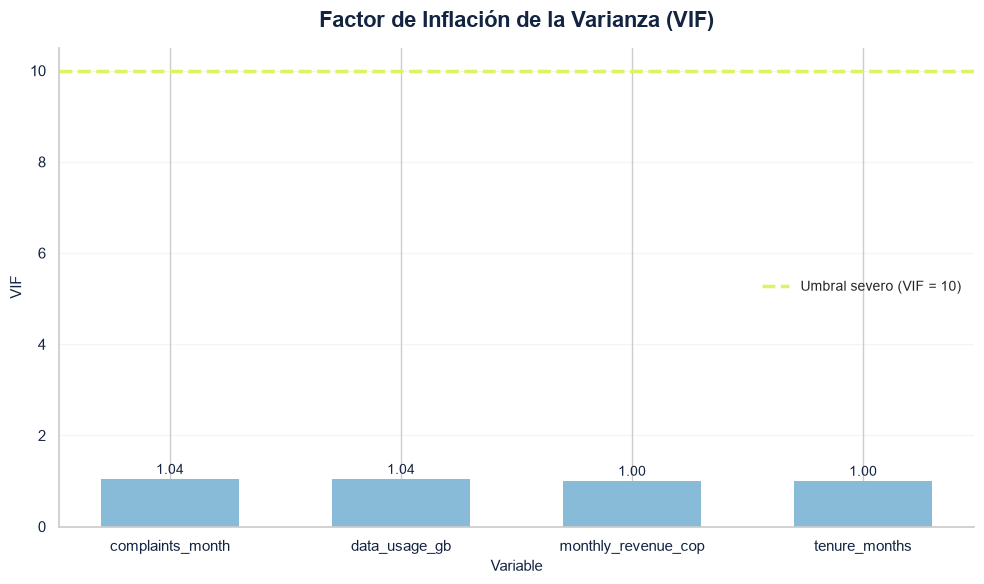

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
 
barras = ax.bar(
    vif["Variable"],
    vif["VIF"],
    color="#87BBD7",
    edgecolor="none",
    width=0.6
)
 
ax.axhline(
    y=10,
    color="#DAF561",
    linestyle="--",
    linewidth=2.5,
    label="Umbral severo (VIF = 10)"
)
 
for barra, valor in zip(barras, vif["VIF"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.05,
        f"{valor:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#132441"
    )
 
ax.set_title(
    "Factor de Inflación de la Varianza (VIF)",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)
 
ax.set_xlabel("Variable", fontsize=11, color="#132441")
ax.set_ylabel("VIF", fontsize=11, color="#132441")
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", colors="#132441")
ax.set_xticks(range(len(vif)))
ax.set_xticklabels(
    vif["Variable"],
    rotation=0,
    ha="center"
)
 
ax.legend(frameon=False, fontsize=10)
 
plt.tight_layout()
plt.show()

**Su conclusión:** _Los valores de VIF obtenidos fueron 1.04 para complaints_month y data_usage_gb, 1.00 para monthly_revenue_cop y tenure_months. Ninguna de las variables presentes en el análisis supera el umbral de 5, ni el umbral severo de 10. Por lo tanto, no existe evidencia de multicolinealidad severa entre las variables. Los valores cercanos a 1 indican que las variables presentan una baja dependencia lineal entre sí, por lo que pueden incluirse conjuntamente en análisis posteriores sin que la multicolinealidad represente un problema importante._

## A3. Patrón de ausencia con missingno

**Propósito:** usen `msno.matrix` sobre el dataset completo. Como `nps_score` tiene muchos más nulos que cualquier otra columna (~80%), ¿el patrón visual sugiere que la ausencia se concentra en algún tramo del archivo, o está dispersa?

/var/folders/8n/1r66cxq95cqfl4msl6vm9qs80000gn/T/ipykernel_3399/3030718057.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


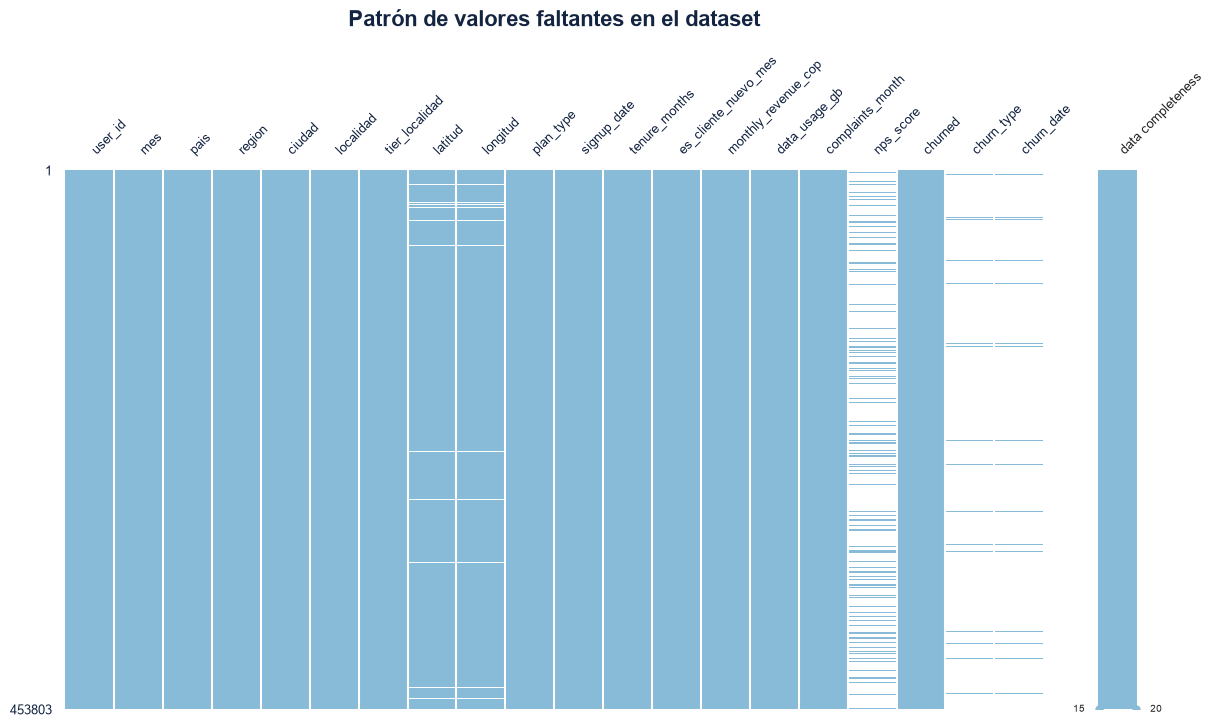

In [55]:
powder_blue = mcolors.to_rgb("#87BBD7")
midnight_blue = "#132441"

ax = msno.matrix(
    df,
    figsize=(14, 7),
    color=powder_blue,
    sparkline=True,
    fontsize=9,
    labels=True
)
 
ax.set_facecolor("#FFFFFF")
ax.figure.set_facecolor("#FFFFFF")
 
ax.set_title(
    "Patrón de valores faltantes en el dataset",
    fontsize=16,
    fontweight="bold",
    color=midnight_blue,
    pad=20
)
 
ax.tick_params(
    axis="both",
    colors=midnight_blue,
    labelsize=9
)
 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
 
plt.tight_layout()
plt.show()

**Su conclusión:** _`msno.matrix(df)` muestra dos franjas blancas dominantes: `nps_score` con ausencia dispersa y uniforme a lo largo de todo el índice (no concentrada en un bloque de filas), y `latitud`/`longitud` con 6.805 huecos también dispersos. `churn_type`/`churn_date` aparecen blancas en 97.09% pero es esperable (solo aplica a churn=1, no es dato faltante real). La ausencia parece fila a fila, compatible con MAR (Missing At Random) / MNAR (MNAR — Missing Not At Random) para NPS y con error aleatorio de geocodificación para coordenadas._

## A4. Coordenadas

**Propósito:** revisen `latitud` y `longitud`. Colombia está aproximadamente entre 0° y 13° de latitud norte, y entre -66° y -80° de longitud. Identifiquen nulos, valores en (0, 0), y valores fuera de rango. Decidan qué hacer con cada tipo de problema.

In [56]:
# TODO: nulos en latitud/longitud
# TODO: valores en (0, 0), "null island"
# TODO: valores fuera de rango de Colombia (latitud 0-13, longitud -80 a -66)
nulos_coordenadas = df[["latitud", "longitud"]].isnull().sum()
 
filas_con_nulos = df[
    df["latitud"].isna() | df["longitud"].isna()
]
 
null_island = df[
    (df["latitud"] == 0) &
    (df["longitud"] == 0)
]
 
fuera_rango = df[
    (df["latitud"] < 0) |
    (df["latitud"] > 13) |
    (df["longitud"] < -80) |
    (df["longitud"] > -66)
]
 
print("NULOS POR COLUMNA")
print(nulos_coordenadas)
 
print("\nFilas con al menos una coordenada nula:", len(filas_con_nulos))
print("Valores en (0, 0) - Null Island:", len(null_island))
print("Valores fuera del rango de Colombia:", len(fuera_rango))
resumen_coordenadas = pd.DataFrame({
    "Problema": [
        "Latitud nula",
        "Longitud nula",
        "Al menos una coordenada nula",
        "Coordenadas en (0, 0)",
        "Coordenadas fuera del rango de Colombia"
    ],
    "Cantidad": [
        df["latitud"].isna().sum(),
        df["longitud"].isna().sum(),
        len(filas_con_nulos),
        len(null_island),
        len(fuera_rango)
    ]
})
 
resumen_coordenadas["Porcentaje"] = (
    resumen_coordenadas["Cantidad"] / len(df) * 100
).round(2)
 
display(resumen_coordenadas)

NULOS POR COLUMNA
latitud     6805
longitud    6805
dtype: int64

Filas con al menos una coordenada nula: 6805
Valores en (0, 0) - Null Island: 1362
Valores fuera del rango de Colombia: 6446


,Problema,Cantidad,Porcentaje
0,Latitud nula,6805,1.50
1,Longitud nula,6805,1.50
2,Al menos una coordenada nula,6805,1.50
3,"Coordenadas en (0, 0)",1362,0.30
4,Coordenadas fuera del rango de Colombia,6446,1.42


**Su conclusión:** Coordenadas nulas: Se identificaron 685 registros con coordenadas nulas. Se decidió marcarlos inicialmente como valores faltantes y no eliminarlos, ya que el dataset cuenta con información geográfica adicional con la que puede diligenciarse. Posteriormente, pueden imputarse utilizando las coordenadas representativas de registros pertenecientes a la misma localidad o, si no fuera posible, a la misma ciudad. Por ejemplo, si un usuario de Bogotá tiene latitud y longitud nulas, se podría calcular la mediana de las coordenadas válidas de los demás registros de Bogotá y utilizar esos valores para completar su ubicación.
 
Coordenadas en (0, 0): Se encontraron 1.362 registros con coordenadas (0, 0). Debido a que esta ubicación no corresponde a una posición válida para Colombia, se decidió convertir estos valores en coordenadas faltantes. Posteriormente, podrán tratarse de la misma manera que los nulos e imputarse utilizando la información de localidad o ciudad. Por ejemplo, si un registro tiene (0, 0) pero pertenece a una determinada localidad, se podría reemplazar por la mediana de las coordenadas válidas de los demás usuarios registrados en esa misma localidad.
 
Coordenadas fuera del rango de Colombia: Se identificaron 646 registros con coordenadas fuera del rango geográfico establecido para Colombia. Se decidió marcarlos como inválidos y revisar si es posible recuperar o corregir su ubicación utilizando las variables pais, region, ciudad y localidad. Por ejemplo, si un registro indica que pertenece a Bogotá, pero sus coordenadas están fuera del rango de Colombia, se pueden comparar con las coordenadas válidas de otros registros de Bogotá para evaluar una posible corrección. Si no pueden corregirse de manera confiable, estos registros se excluirán únicamente de los análisis geográficos, conservando el resto de su información para otros análisis.

## A5. Texto inconsistente

**Propósito:** normalicen `region` y `plan_type` a un conjunto único de valores. Documenten qué variantes encontraron antes de unificarlas.

In [59]:
# TODO: apliquen normalizar_texto() a region y plan_type
print("Valores antes de normalizar")
print("Region:\n",df["region"].value_counts())
print("\nPlan_type:\n",df["plan_type"].value_counts())

Valores antes de normalizar
Region:
 region
Andina       273614
Caribe        79269
Pacifica      72201
Orinoquia     20399
Amazonia       8320
Name: count, dtype: int64

Plan_type:
 plan_type
Prepago        181478
Pospago        159174
Convergente    113151
Name: count, dtype: int64


In [60]:

print("\nValores despues de normalizar")
df['region'] = df['region'].apply(lambda x: normalizar_texto(x))
df['plan_type'] = df['plan_type'].apply(lambda x: normalizar_texto(x))
print("Region:\n",df["region"].value_counts())
print("\nPlan_type:\n",df["plan_type"].value_counts())


Valores despues de normalizar
Region:
 region
Andina       273614
Caribe        79269
Pacifica      72201
Orinoquia     20399
Amazonia       8320
Name: count, dtype: int64

Plan_type:
 plan_type
Prepago        181478
Pospago        159174
Convergente    113151
Name: count, dtype: int64


**Su conclusión:**

En region se encontraron 10 valores distintos, que realmente corresponden a solo 5 regiones. Las diferencias estaban en tildes, por ejemplo, Pacífica y Pacifica. Después de aplicar la normalización, las categorías se unificaron en 5 valores: Andina, Caribe, Pacifica, Orinoquia y Amazonia.
 
En plan_type se identificaron 6 valores distintos que correspondían realmente a 3 categorías, debido a inconsistencias en las mayúsculas y minúsculas. Por ejemplo, Prepago y PREPAGO. Después de normalizar los valores, quedaron únicamente las categorías Prepago, Pospago y Convergente.
 
La normalización permitió unificar etiquetas equivalentes sin modificar la cantidad de registros, ya que el total se mantuvo sin eliminar ni duplicar registros.

## A6. Duplicados

**Propósito:** verifiquen si hay filas exactamente duplicadas. Antes de eliminarlas, confirmen que realmente son duplicados de carga y no dos eventos legítimos del mismo usuario en el mismo mes.

In [61]:
# TODO: df.duplicated().sum()
# TODO: revisen si los duplicados coinciden en user_id + mes, o son coincidencias parciales en otras columnas
df.duplicated().sum()

duplicados_exactos = df.duplicated().sum()
 
print("Cantidad de filas exactamente duplicadas:", duplicados_exactos)
 
df_duplicados = df[df.duplicated(keep=False)]
 
resumen_duplicados = (
    df_duplicados
    .groupby(["user_id", "mes"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)
 
print("\nCombinaciones repetidas de user_id + mes:")
display(resumen_duplicados.head(10))
 
cantidad_repetidos = (resumen_duplicados["cantidad"] > 1).sum()
 
print(
    "\nCantidad de combinaciones user_id + mes repetidas:",
    cantidad_repetidos
)



Cantidad de filas exactamente duplicadas: 1355

Combinaciones repetidas de user_id + mes:


,user_id,mes,cantidad
0,CNX-100180,2026-04,2
900,CNX-201915,2026-03,2
908,CNX-202262,2026-05,2
907,CNX-202213,2026-05,2
906,CNX-202153,2026-03,2
905,CNX-202089,2026-04,2
904,CNX-202089,2026-03,2
903,CNX-202082,2026-04,2
902,CNX-202047,2026-03,2
901,CNX-201922,2026-05,2



Cantidad de combinaciones user_id + mes repetidas: 1355


In [48]:
df_sin_duplicados = df.drop_duplicates()
 
print("Filas antes:", len(df))
print("Filas después:", len(df_sin_duplicados))
print("Duplicados eliminados:", len(df) - len(df_sin_duplicados))

Filas antes: 453803
Filas después: 452448
Duplicados eliminados: 1355


**Su conclusión:** _Se encontraron 1.355 filas exactamente duplicadas. Se concluyó que son duplicados de carga y no eventos legítimos porque cada fila identificada como duplicada coincide exactamente en todas las columnas del dataset, no solo en user_id y mes. Además, al revisar estas filas, se observó que las combinaciones de user_id + mes aparecen repetidas con una cantidad de 2, pero sin presentar diferencias en ninguna de las demás variables. Por lo tanto, no existe evidencia de que representen dos eventos distintos, sino que corresponden a la misma información registrada dos veces._

## A7. El caso de `nps_score`: ¿por qué falta?

**Propósito:** calculen el % de nulos en `nps_score`, y compárenlo entre usuarios con `churned=1` y `churned=0`. En clase vieron tres tipos de ausencia (MCAR, MAR, MNAR): usen esa comparación, junto con lo que ya saben del negocio de CONECTA, para argumentar cuál de los tres aplica aquí y por qué, no solo para reportar el número. Con esa conclusión, justifiquen por escrito qué van a hacer con la columna: ¿la imputan, dejan el nulo, o la excluyen de ciertos análisis?

          total   nulos  porcentaje_nulos
churned                                  
0        439274  357645             81.42
1         13174    6622             50.27


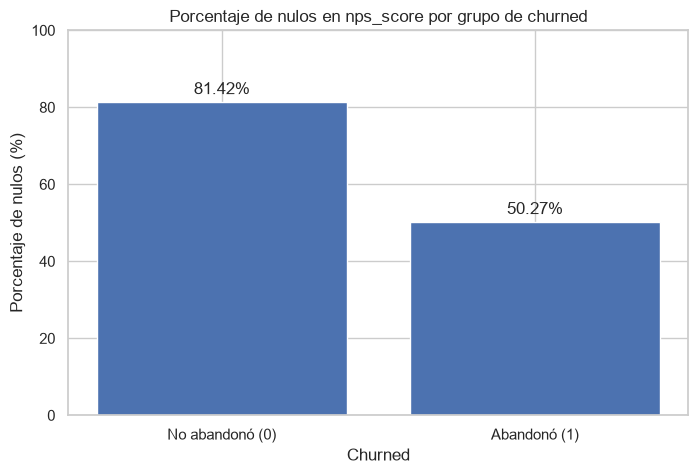

In [62]:
# TODO: % de nulos en nps_score, total y por grupo de churned (0 vs 1)

resumen_nulos_nps = df_sin_duplicados.groupby('churned')['nps_score'].agg(
    total='size',
    nulos=lambda x: x.isna().sum(),
    porcentaje_nulos=lambda x: x.isna().mean() * 100
)

print(resumen_nulos_nps)

plt.figure(figsize=(8, 5))

plt.bar(
    resumen_nulos_nps.index.astype(str),
    resumen_nulos_nps['porcentaje_nulos']
)

plt.title('Porcentaje de nulos en nps_score por grupo de churned')
plt.xlabel('Churned')
plt.ylabel('Porcentaje de nulos (%)')

plt.xticks(
    ticks=[0, 1],
    labels=['No abandonó (0)', 'Abandonó (1)']
)

plt.ylim(0, 100)

for i, valor in enumerate(resumen_nulos_nps['porcentaje_nulos']):
    plt.text(i, valor + 2, f'{valor:.2f}%', ha='center')

plt.show()

**Su conclusión:** 
La variable nps_score presenta un nivel muy alto de valores faltantes. Al comparar los grupos, los usuarios que no abandonaron el servicio, correspondientes a churned = 0, tienen 357.645 valores nulos, equivalentes al 81.42%, mientras que los usuarios que sí abandonaron, correspondientes a churned = 1, tienen 6.622 valores nulos, equivalentes al 50.27%. Esta diferencia de más de 31 puntos porcentuales muestra que la ausencia de nps_score no parece estar distribuida de manera completamente aleatoria entre todos los usuarios.

Por esta razón, el patrón no presenta indicios de MCAR, ya que la probabilidad de que falte el valor cambia según una variable observada como churned. Los resultados proporcionan evidencia de un patrón compatible con MAR, porque la ausencia de nps_score parece estar relacionada con el estado de abandono del cliente. Sin embargo, esta comparación por sí sola no permite demostrar definitivamente el mecanismo de ausencia ni descartar completamente un posible patrón MNAR. Desde la perspectiva del negocio, podría indicar que los clientes que abandonan tienen una mayor probabilidad de contar con una medición de satisfacción, posiblemente porque su experiencia o proceso de salida genera una mayor oportunidad para recopilar esta información.

Debido a que nps_score tiene una proporción muy alta de valores faltantes, no se recomienda imputar masivamente la columna, ya que se estaría estimando una gran cantidad de valores y podrían introducirse sesgos en los análisis. Por ello, se decidió mantener los valores nulos y utilizar nps_score únicamente en los análisis donde sea relevante, considerando los registros que cuentan con una medición válida y teniendo presente que la ausencia está asociada con churned.

## A8. Outliers: tres métodos, no uno solo

**Propósito:** apliquen a `monthly_revenue_cop` los tres métodos vistos en clase: Tukey (Q1-1.5×IQR a Q3+1.5×IQR), Modified Z-score con MAD (Iglewicz & Hoaglin, 1993, umbral 3.5), e Isolation Forest (multivariado, sobre `monthly_revenue_cop`, `data_usage_gb`, `complaints_month`). Comparen los tres conjuntos de outliers: ¿coinciden en gran medida, o cada método señala casos distintos? Relacionen la diferencia con lo que ya observaron sobre estas variables en el correlograma del taller de S2.

In [ ]:
# TODO: Tukey IQR sobre monthly_revenue_cop
# TODO: Modified Z-score (MAD) sobre monthly_revenue_cop
# TODO: Isolation Forest sobre monthly_revenue_cop, data_usage_gb, complaints_month

# 1. TUKEY (IQR) sobre monthly_revenue_cop

Q1 = df["monthly_revenue_cop"].quantile(0.25)
Q3 = df["monthly_revenue_cop"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_tukey = (
    (df["monthly_revenue_cop"] < limite_inferior) |
    (df["monthly_revenue_cop"] > limite_superior)
)

# 2. MODIFIED Z-SCORE con MAD sobre monthly_revenue_cop

mediana = df["monthly_revenue_cop"].median()
MAD = median_abs_deviation(
    df["monthly_revenue_cop"],
    scale=1,
    nan_policy="omit"
)

modified_z = (
    0.6745 * (df["monthly_revenue_cop"] - mediana) / MAD
)

outliers_mad = modified_z.abs() > 3.5

# 3. ISOLATION FOREST - método multivariado

variables_if = [
    "monthly_revenue_cop",
    "data_usage_gb",
    "complaints_month"
]

X_if = df[variables_if].dropna()

modelo_if = IsolationForest(
    contamination=0.01,
    random_state=42
)

predicciones_if = modelo_if.fit_predict(X_if)

outliers_if = pd.Series(
    predicciones_if == -1,
    index=X_if.index
)

# 4. RESUMEN DE RESULTADOS

print("OUTLIERS DETECTADOS")
print("-" * 40)
print(f"Tukey (IQR): {outliers_tukey.sum()}")
print(f"Modified Z-score (MAD): {outliers_mad.sum()}")
print(f"Isolation Forest: {outliers_if.sum()}")

# 5. COMPARACIÓN ENTRE MÉTODOS

indices_tukey = set(df.index[outliers_tukey])
indices_mad = set(df.index[outliers_mad])
indices_if = set(outliers_if[outliers_if].index)

print("\nCOINCIDENCIA ENTRE MÉTODOS")
print("-" * 40)
print("Tukey ∩ MAD:", len(indices_tukey & indices_mad))
print("Tukey ∩ Isolation Forest:", len(indices_tukey & indices_if))
print("MAD ∩ Isolation Forest:", len(indices_mad & indices_if))
print(
    "Coinciden los tres:",
    len(indices_tukey & indices_mad & indices_if)
)

OUTLIERS DETECTADOS
----------------------------------------
Tukey (IQR): 15813
Modified Z-score (MAD): 10875
Isolation Forest: 4539

COINCIDENCIA ENTRE MÉTODOS
----------------------------------------
Tukey ∩ MAD: 10875
Tukey ∩ Isolation Forest: 1983
MAD ∩ Isolation Forest: 1834
Coinciden los tres: 1834


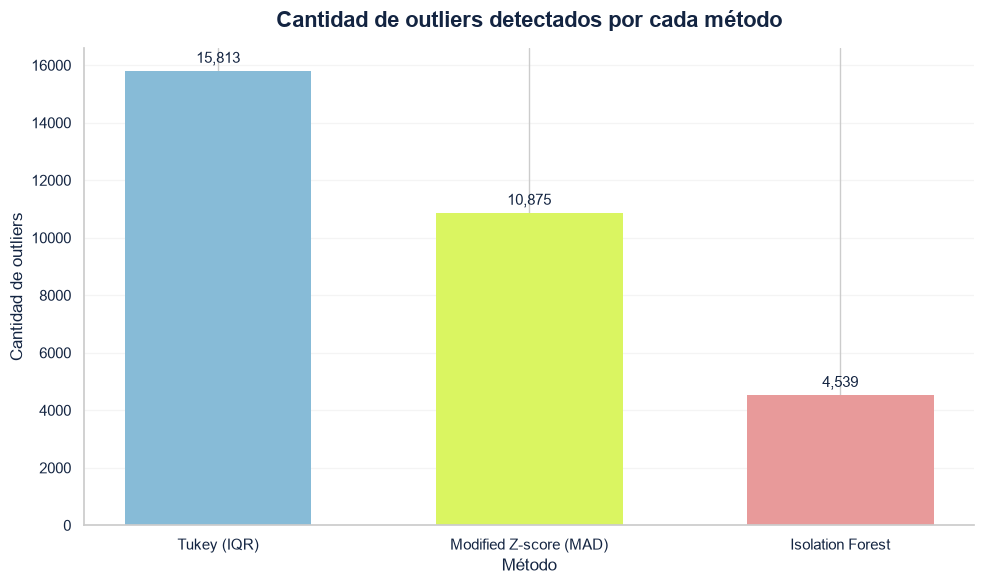

In [ ]:
resumen_outliers = pd.DataFrame({
    "Método": [
        "Tukey (IQR)",
        "Modified Z-score (MAD)",
        "Isolation Forest"
    ],
    "Cantidad": [
        outliers_tukey.sum(),
        outliers_mad.sum(),
        outliers_if.sum()
    ]
})

fig, ax = plt.subplots(figsize=(10, 6))

colores = ["#87BBD7", "#DAF561", "#E89A9A"]

barras = ax.bar(
    resumen_outliers["Método"],
    resumen_outliers["Cantidad"],
    color=colores,
    edgecolor="none",
    width=0.6
)

for barra, valor in zip(barras, resumen_outliers["Cantidad"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + resumen_outliers["Cantidad"].max() * 0.01,
        f"{valor:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#132441"
    )

ax.set_title(
    "Cantidad de outliers detectados por cada método",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)

ax.set_xlabel("Método", fontsize=12, color="#132441")
ax.set_ylabel("Cantidad de outliers", fontsize=12, color="#132441")

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", colors="#132441")

plt.tight_layout()
plt.show()

**Su conclusión:** Al aplicar los tres métodos de detección de outliers sobre las variables analizadas, se encontraron diferencias importantes en la cantidad de casos identificados. El método de Tukey (IQR) detectó 15.813 outliers, siendo el método que identificó más casos; el Modified Z-score basado en MAD detectó 10.875, mientras que Isolation Forest identificó 4.539 observaciones atípicas. Aunque existe coincidencia entre los métodos, esta no es completa: Tukey y MAD coinciden en 10.875 casos, Tukey e Isolation Forest en 1.983, y MAD e Isolation Forest en 1.834. En total, 1.834 registros fueron identificados simultáneamente por los tres métodos. Estos resultados muestran que los métodos no señalan exactamente los mismos casos, ya que cada uno utiliza un criterio diferente para definir una observación como atípica. Tukey y Modified Z-score presentan una coincidencia considerable porque ambos evalúan principalmente valores extremos de monthly_revenue_cop, mientras que Isolation Forest analiza conjuntamente monthly_revenue_cop, data_usage_gb y complaints_month, por lo que identifica patrones anómalos multivariados. Esta diferencia es coherente con lo observado previamente en el correlograma, donde estas variables presentaban correlaciones bajas o moderadas, lo que significa que los casos extremos en una variable no necesariamente son anómalos cuando se consideran las tres variables en conjunto.

## A9. Imputación comparada, si aplica

**Propósito:** si su grupo decide imputar algún valor (no necesariamente coordenadas), comparen al menos dos métodos (por ejemplo mediana por grupo vs. KNN) con un gráfico de densidades superpuestas antes de aplicar uno. Si el dataset no requiere imputación en ninguna columna numérica, documenten por qué no es necesaria, en vez de omitir el punto.

In [66]:
# TODO: si aplica, comparen al menos 2 métodos de imputación con un gráfico de densidades superpuestas
# (sns.kdeplot de la variable original sin nulos contra cada método candidato)

# A9. Imputación comparada de coordenadas

df_coord = df_sin_duplicados.copy()

coord_invalidas = (
    df_coord["latitud"].isna() |
    df_coord["longitud"].isna() |
    ((df_coord["latitud"] == 0) & (df_coord["longitud"] == 0)) |
    (df_coord["latitud"] < 0) |
    (df_coord["latitud"] > 13) |
    (df_coord["longitud"] < -80) |
    (df_coord["longitud"] > -66)
)

df_coord.loc[coord_invalidas, ["latitud", "longitud"]] = np.nan

print("Registros con coordenadas faltantes después de la limpieza:")
print(df_coord[["latitud", "longitud"]].isna().sum())

Registros con coordenadas faltantes después de la limpieza:
latitud     13208
longitud    13208
dtype: int64


In [67]:
df_mediana = df_coord.copy()

for columna in ["latitud", "longitud"]:
    
    df_mediana[columna] = (
        df_mediana.groupby("localidad")[columna]
        .transform(lambda x: x.fillna(x.median()))
    )

for columna in ["latitud", "longitud"]:
    
    df_mediana[columna] = (
        df_mediana.groupby("ciudad")[columna]
        .transform(lambda x: x.fillna(x.median()))
    )

print("Nulos después de imputar con localidad → ciudad:")
print(df_mediana[["latitud", "longitud"]].isna().sum())

Nulos después de imputar con localidad → ciudad:
latitud     0
longitud    0
dtype: int64


In [68]:
df_knn = df_coord.copy()

variables_knn = [
    "latitud",
    "longitud",
    "tenure_months",
    "monthly_revenue_cop",
    "data_usage_gb",
    "complaints_month"
]

scaler = StandardScaler()

X = df_knn[variables_knn]

X_scaled = scaler.fit_transform(X)

imputer_knn = KNNImputer(
    n_neighbors=5,
    weights="distance"
)

X_imputado_scaled = imputer_knn.fit_transform(X_scaled)

X_imputado = scaler.inverse_transform(X_imputado_scaled)

df_knn[variables_knn] = X_imputado

print("Nulos después de imputar con KNN:")
print(df_knn[["latitud", "longitud"]].isna().sum())

Nulos después de imputar con KNN:
latitud     0
longitud    0
dtype: int64


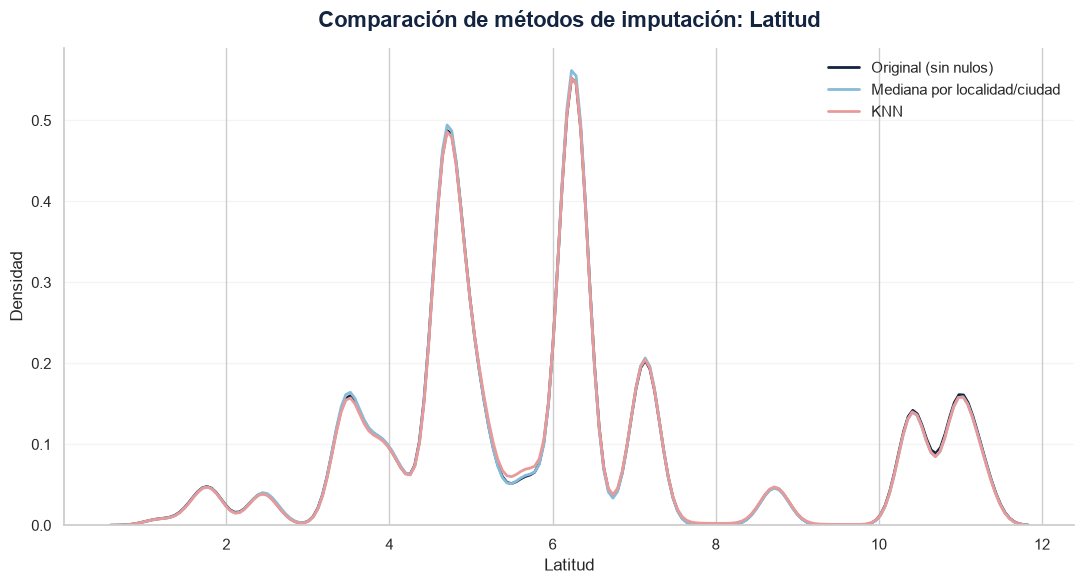

In [ ]:
latitud_original = df_coord["latitud"].dropna()

fig, ax = plt.subplots(figsize=(11, 6))

sns.kdeplot(
    latitud_original,
    label="Original (sin nulos)",
    linewidth=2,
    color="#132441",
    ax=ax
)

sns.kdeplot(
    df_mediana["latitud"],
    label="Mediana por localidad/ciudad",
    linewidth=2,
    color="#87BBD7",
    ax=ax
)

sns.kdeplot(
    df_knn["latitud"],
    label="KNN",
    linewidth=2,
    color="#E89A9A",
    ax=ax
)

ax.set_title(
    "Comparación de métodos de imputación: Latitud",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)

ax.set_xlabel("Latitud", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

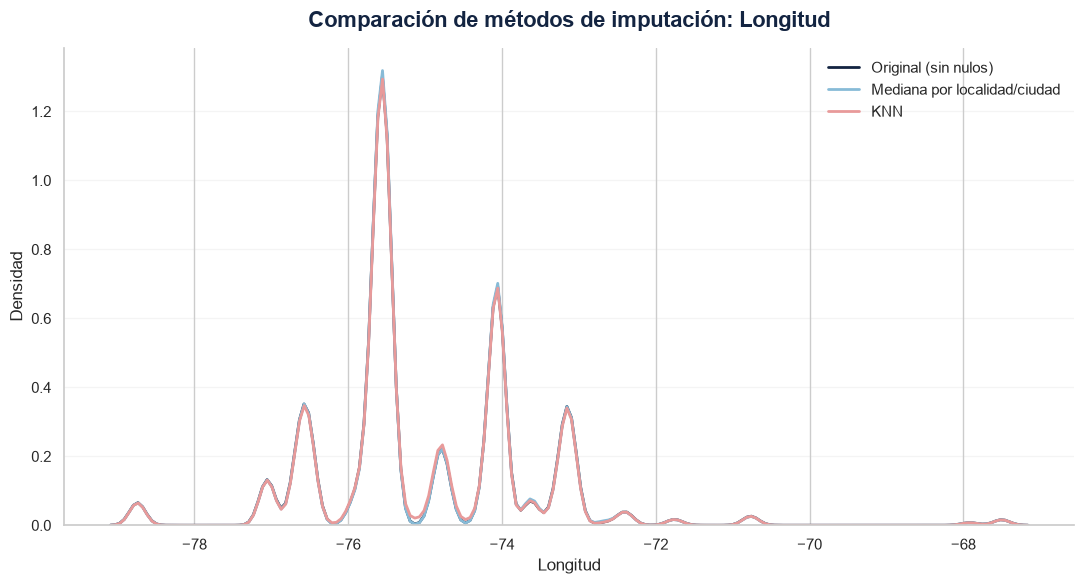

In [ ]:
longitud_original = df_coord["longitud"].dropna()

fig, ax = plt.subplots(figsize=(11, 6))

sns.kdeplot(
    longitud_original,
    label="Original (sin nulos)",
    linewidth=2,
    color="#132441",
    ax=ax
)

sns.kdeplot(
    df_mediana["longitud"],
    label="Mediana por localidad/ciudad",
    linewidth=2,
    color="#87BBD7",
    ax=ax
)

sns.kdeplot(
    df_knn["longitud"],
    label="KNN",
    linewidth=2,
    color="#E89A9A",
    ax=ax
)

ax.set_title(
    "Comparación de métodos de imputación: Longitud",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)

ax.set_xlabel("Longitud", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**Su conclusión:** 
Se decidió imputar las columnas latitud y longitud, ya que presentaban valores faltantes e inválidos que podían recuperarse utilizando información geográfica disponible en el dataset. Se compararon dos métodos: la imputación mediante mediana jerárquica por localidad y, cuando fue necesario, por ciudad, y el método KNN. Las gráficas de densidad mostraron que ambos métodos conservaron una distribución muy similar a la de los valores originales. Sin embargo, se seleccionó la imputación por mediana jerárquica, debido a que localidad y ciudad tienen una relación directa con la ubicación geográfica y, por lo tanto, proporcionan una base más interpretable y adecuada para estimar las coordenadas faltantes.

Las demás columnas numéricas no se imputaron porque no presentaban valores faltantes que requirieran este tratamiento, o porque su imputación podía introducir sesgos en los análisis. En particular, nps_score presenta una proporción elevada de valores faltantes y su ausencia mostró una relación con churned, por lo que imputar masivamente sus valores podría generar estimaciones poco confiables. Por esta razón, se mantuvieron sus valores nulos y la variable se utilizará únicamente en los análisis donde se cuente con una medición válida, considerando la posible relación entre su ausencia y el abandono del cliente.

## A10. Documentación de decisiones

**Propósito:** por cada corrección aplicada, una línea: qué se encontró, qué método formal se usó (si aplica), qué se decidió, y por qué.


| Problema encontrado | Método formal usado | Decisión | Por qué |
|---|---|---|---|
| Posibles relaciones lineales entre variables numéricas | Matriz de correlación de Pearson | Se mantuvieron las variables sin eliminar ninguna por correlación | No se encontraron relaciones de negocio suficientemente altas entre las variables analizadas que justificaran eliminar una por redundancia. La correlación alta entre latitud y longitud corresponde a la distribución geográfica. |
| Posible multicolinealidad entre variables numéricas | Variance Inflation Factor (VIF) | Se mantuvieron tenure_months, monthly_revenue_cop, data_usage_gb y complaints_month | Todos los VIF estuvieron cercanos a 1 y ninguno superó los umbrales de 5 o 10, por lo que no existe evidencia de multicolinealidad severa. |
| Valores faltantes, especialmente en nps_score | Matriz de valores faltantes con missingno | Se mantuvieron inicialmente los valores nulos para analizarlos por separado | El patrón visual mostró que los faltantes de nps_score están dispersos en el dataset y no concentrados únicamente en un tramo específico del archivo. |
| Coordenadas nulas o incompletas | Validación de nulos en latitud y longitud | Se trataron como valores faltantes y se imputaron utilizando información de ubicación | Las variables localidad y ciudad permiten recuperar coordenadas de manera más coherente que una imputación global. |
| Coordenadas con valores (0, 0) | Regla de validación geográfica, identificando "Null Island" | Se convirtieron en valores faltantes antes de la imputación | (0, 0) no corresponde a una ubicación válida para Colombia, por lo que estos valores representan coordenadas inválidas y no ubicaciones reales de los clientes. |
| Coordenadas fuera del rango geográfico de Colombia | Validación por rango: latitud entre 0 y 13 y longitud entre -80 y -66 | Se consideraron inválidas y se convirtieron en valores faltantes para su recuperación | Los valores fuera de estos rangos no corresponden a ubicaciones esperadas en Colombia y podían afectar los análisis geográficos. |
| Categorías inconsistentes en region y plan_type | Normalización de texto mediante normalizar_texto() | Se unificaron etiquetas equivalentes | Se eliminaron diferencias causadas por tildes y mayúsculas/minúsculas sin modificar el número total de registros. |
| Filas exactamente duplicadas | df.duplicated() y revisión de combinaciones user_id + mes | Se identificaron como duplicados de carga y se consideró su eliminación | Se encontraron 1.355 filas exactamente duplicadas y las combinaciones repetidas de usuario y mes aparecían dos veces, sin diferencias en las demás columnas que indicaran eventos distintos. |
| Alta ausencia de nps_score | Comparación del porcentaje de nulos por churned | No se imputó nps_score; se mantuvieron sus valores nulos | La ausencia difiere considerablemente entre los grupos de abandono, por lo que no parece MCAR y es compatible con un posible mecanismo MAR. Imputar una proporción tan alta podría introducir sesgos y valores artificiales. |
| Valores extremos en monthly_revenue_cop | Tukey IQR, Modified Z-score con MAD e Isolation Forest | Los outliers se identificaron y compararon, pero no se eliminaron automáticamente | Los métodos detectaron cantidades diferentes y coincidieron solo parcialmente, mostrando que no todos los valores extremos son necesariamente errores. Se requiere considerar el contexto antes de eliminarlos. |
| Coordenadas faltantes e inválidas | Comparación entre mediana jerárquica por localidad/ciudad y KNN, mediante gráficos KDE | Se eligió la imputación jerárquica por localidad y luego ciudad | Ambos métodos conservaron distribuciones similares a la original, pero localidad y ciudad tienen una relación directa con la ubicación geográfica, por lo que el método elegido es más interpretable y adecuado. |

In [ ]:
# TODO: apliquen aquí todas las correcciones que decidieron arriba, sobre una copia del dataframe
# En las secciones anteriores, se aplicaron los metodos de imputación, la normalizacion y limpieza de duplicados. 
df_limpio = df.copy()

df_limpio.to_csv(os.path.join("", "dataset_limpio.csv"), index=False)
print("Nulos restantes:", df_limpio.isnull().sum().sum())
df_limpio.head()

Nulos restantes: 1260109


,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


## Entregable Parte A

`dataset_limpio.csv` (ya guardado arriba) más la tabla de decisiones del punto A10 completa.

# Parte B · SCQA y diseño efectivo (S4)

Tomen un hallazgo sobre `dataset_limpio.csv` (generado en la Parte A), verifiquen que se sostenga al considerar otra variable relevante, y comuníquenlo mediante un SCQA y un gráfico efectivo. El centro de esta parte es el SCQA y una primera versión del gráfico que lo sostenga: no tiene que ser la versión final, la van a seguir refinando en sesiones posteriores del curso. El heatmap de `region` x `tier_localidad` y el choropleth construidos en el taller de S2 ya sugieren que ambas dimensiones no son independientes entre sí; tengan esto presente al elegir qué variable considerar.

In [24]:
df = pd.read_csv(os.path.join("", "dataset_limpio.csv"))
df.head()

,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


## B1. Hallazgo y verificación

**Propósito:** identifiquen un hallazgo relevante para CONECTA (por ejemplo, una diferencia en `churned` o en `monthly_revenue_cop` asociada a alguna variable). Verifíquenlo considerando al menos una variable adicional (`region`, `tier_localidad`, `mes`, `plan_type`), con el método que corresponda a su pregunta: regresión, comparación de tasas o promedios, tabla cruzada. No todo hallazgo requiere un modelo. Reporten si el hallazgo se sostiene, se debilita, o desaparece al considerar esa variable.

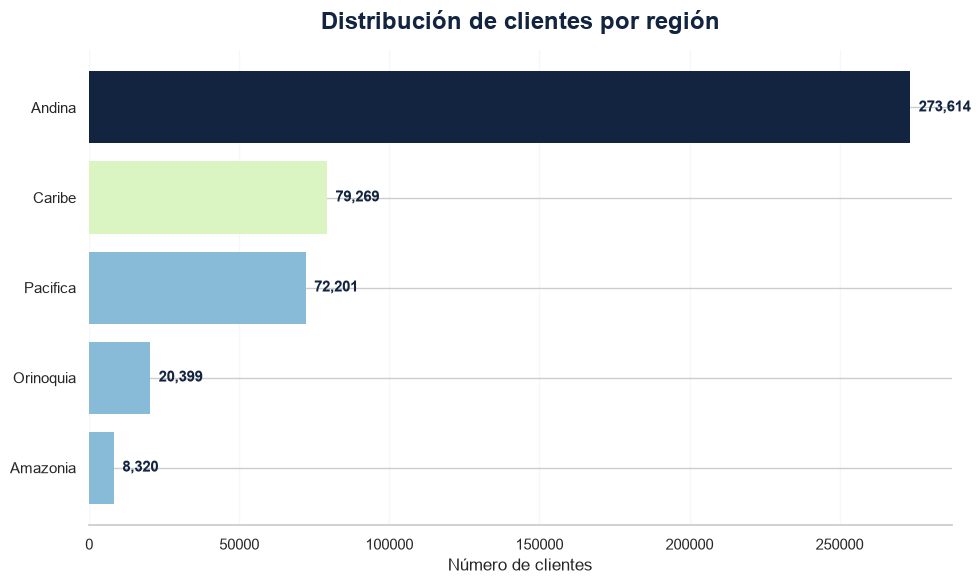

In [66]:
clientes_region = (
    df.groupby("region")
      .size()
      .sort_values(ascending=True)
)
 
# Colores: Caribe destacado
colores = [
    "#87BBD7" if region not in ["Caribe", "Andina"] else
    "#DAF5C1" if region == "Caribe" else
    "#132441"
    for region in clientes_region.index
]
 
fig, ax = plt.subplots(figsize=(10, 6))
 
bars = ax.barh(
    clientes_region.index,
    clientes_region.values,
    color=colores,
    edgecolor="none"
)
 
# Valores sobre las barras
for bar, valor in zip(bars, clientes_region.values):
    ax.text(
        bar.get_width() + clientes_region.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:,.0f}",
        va="center",
        fontsize=11,
        color="#132441",
        fontweight="bold"
    )
 
ax.set_title(
    "Distribución de clientes por región",
    fontsize=17,
    fontweight="bold",
    color="#132441",
    pad=15
)
 
ax.set_xlabel("Número de clientes", fontsize=12)
ax.set_ylabel("")
 
# Diseño minimalista
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
 
ax.grid(
    axis="x",
    alpha=0.15
)
 
plt.tight_layout()
plt.show()

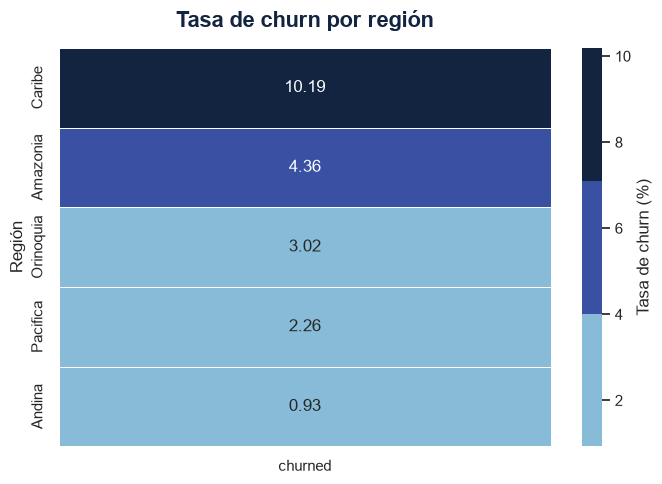

In [61]:
tabla_churn_region = (
    df.groupby("region")["churned"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame()
)
 
plt.figure(figsize=(7, 5))
 
sns.heatmap(
    tabla_churn_region,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        ["#87BBD7", "#3A51A3", "#132441"],
        as_cmap=True
    ),
    linewidths=0.5,
    cbar_kws={"label": "Tasa de churn (%)"}
)
 
plt.title(
    "Tasa de churn por región",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)
 
plt.xlabel("")
plt.ylabel("Región")
 
plt.tight_layout()
plt.show()

In [50]:
# TODO: verifíquenlo considerando al menos una variable adicional relevante
churn_region_plan = (
    df.groupby(["region", "plan_type"])
      .agg(
          clientes=("churned", "size"),
          tasa_churn=("churned", "mean")
      )
      .reset_index()
)
 
churn_region_plan["tasa_churn_pct"] = (
    churn_region_plan["tasa_churn"] * 100
)
 
display(churn_region_plan)

,region,plan_type,clientes,tasa_churn,tasa_churn_pct
0,Amazonia,Convergente,2150,0.05,4.79
1,Amazonia,Pospago,2887,0.04,4.09
2,Amazonia,Prepago,3283,0.04,4.33
3,Andina,Convergente,68158,0.01,0.98
4,Andina,Pospago,95535,0.01,0.91
5,Andina,Prepago,109921,0.01,0.91
6,Caribe,Convergente,19957,0.10,10.16
7,Caribe,Pospago,28331,0.10,10.14
8,Caribe,Prepago,30981,0.10,10.26
9,Orinoquia,Convergente,5122,0.03,2.99


,region,plan_type,clientes,tasa_churn,tasa_churn_pct
0,Amazonia,Convergente,26,0.00,0.00
1,Amazonia,POSPAGO,1,0.00,0.00
2,Amazonia,PREPAGO,1,0.00,0.00
3,Amazonia,Pospago,56,0.12,12.50
4,Amazonia,Prepago,41,0.05,4.88
5,Amazonía,CONVERGENTE,48,0.00,0.00
6,Amazonía,Convergente,2076,0.05,4.96
7,Amazonía,POSPAGO,45,0.02,2.22
8,Amazonía,PREPAGO,69,0.07,7.25
9,Amazonía,Pospago,2785,0.04,3.95


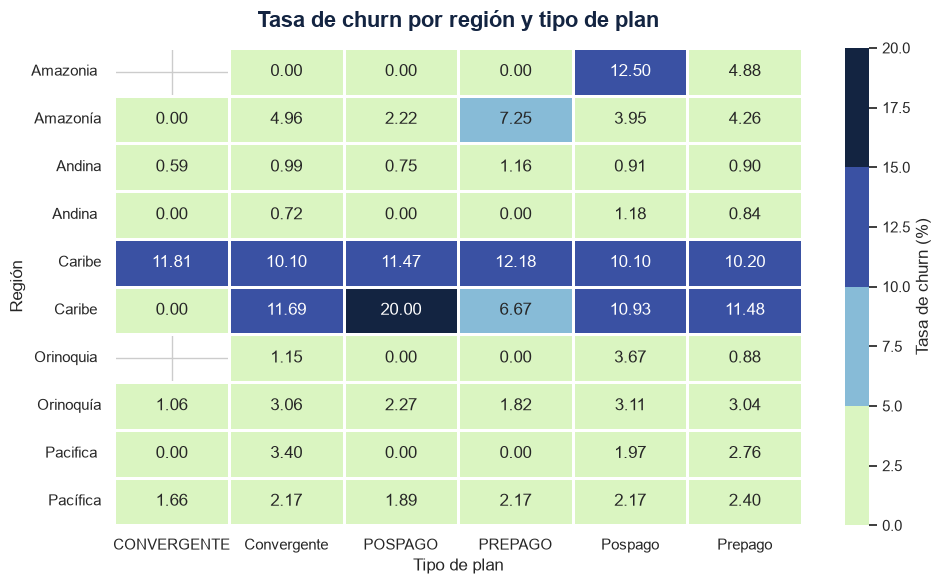

In [21]:
churn_region_plan = (
    df.groupby(["region", "plan_type"])
      .agg(
          clientes=("churned", "size"),
          tasa_churn=("churned", "mean")
      )
      .reset_index()
)
 
churn_region_plan["tasa_churn_pct"] = (
    churn_region_plan["tasa_churn"] * 100
)
 
display(churn_region_plan)
tabla_region_plan = churn_region_plan.pivot(
    index="region",
    columns="plan_type",
    values="tasa_churn_pct"
)
 
plt.figure(figsize=(10, 6))
 
sns.heatmap(
    tabla_region_plan,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        ["#DAF5C1", "#87BBD7", "#3A51A3", "#132441"],
        as_cmap=True
    ),
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Tasa de churn (%)"}
)
 
plt.title(
    "Tasa de churn por región y tipo de plan",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)
 
plt.xlabel("Tipo de plan")
plt.ylabel("Región")
 
plt.tight_layout()
plt.show()

**Su conclusión:** _Hallazgo y verificación: Se encontró que la región Caribe,la segunda región con más clientes, presenta la mayor tasa de churn, con un 10.19%, superando ampliamente a Amazonia (4.36%), Orinoquia (3.02%), Pacífica (2.26%) y Andina (0.93%). Al verificar este comportamiento considerando el tipo de plan, el hallazgo se mantiene: en Caribe las tasas son muy similares entre Convergente (10.16%), Pospago (10.14%) y Prepago (10.26%). Por lo tanto, la diferencia de churn entre regiones se sostiene al considerar plan_type y no parece estar explicada por un tipo de plan específico. Esto sugiere que existen factores asociados a la región Caribe que podrían estar relacionados con el mayor abandono y que sería conveniente explorar posteriormente._

## B2. Escribir el SCQA

**Propósito:** con el hallazgo ya verificado, escriban el SCQA antes de tocar el código del gráfico.

**Situación:** CONECTA cuenta con clientes distribuidos en diferentes regiones del país y ofrece tres tipos de plan: Convergente, Pospago y Prepago.

**Complicación:** La tasa de churn presenta diferencias importantes entre las regiones. Caribe registra la tasa más alta, con 10.19%, mientras que Andina presenta la más baja, con 0.93%. Además, esta diferencia se mantiene al comparar los tres tipos de plan dentro de cada región.

**Pregunta:** ¿La mayor tasa de churn de Caribe se mantiene independientemente del tipo de plan de los clientes?

**Respuesta:** Sí. Caribe presenta las tasas de churn más altas en los tres tipos de plan: 10.16% en Convergente, 10.14% en Pospago y 10.26% en Prepago. Por lo tanto, el mayor churn de Caribe se sostiene al considerar el tipo de plan y no parece estar explicado por un plan específico.

## B3. Primera versión del gráfico efectivo

**Propósito:** construyan una primera versión del gráfico que sostenga la Respuesta del SCQA, aplicando al menos cuatro principios de diseño: tinta proporcional, manejo de superposición si aplica, color con propósito (no arcoíris), codificación redundante si ayuda a accesibilidad, eliminación de desorden, balance dato-contexto. El título debe ser, literalmente, la Respuesta del SCQA. Es un primer intento (MVP), no la versión final: la van a seguir refinando en sesiones posteriores del curso.

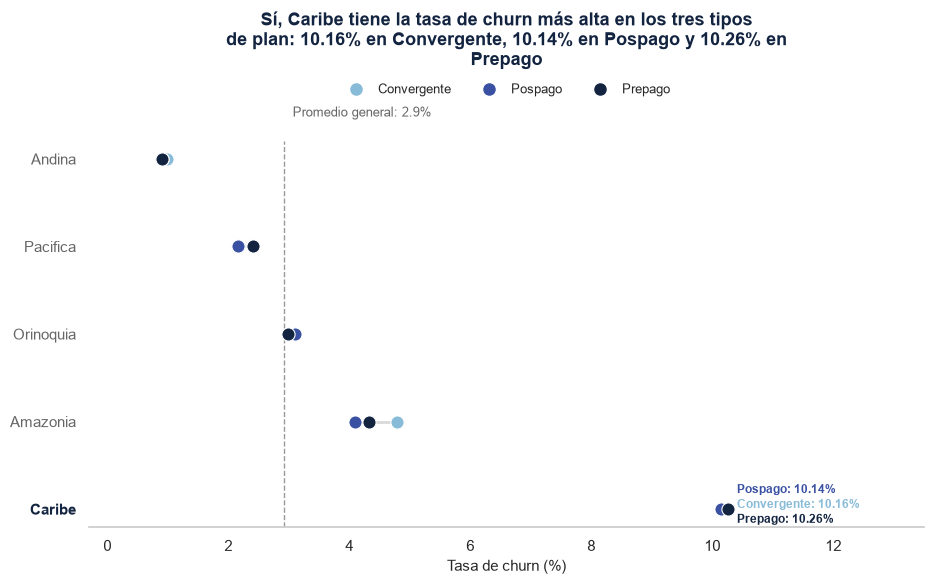

In [ ]:
# TODO: primera versión del gráfico, con el título = la Respuesta del SCQA
# marquen en un comentario cuáles principios aplicaron

# Principios de diseño aplicados:
# -  Manejo de superposición: regiones ordenadas de mayor a menor churn, con una
#    línea guía tenue que une los 3 planes de cada región; en Caribe, donde los
#    tres puntos casi se encimen por lo cercanos que son sus valores, las
#    etiquetas numéricas se apilan a un costado en vez de sobre los puntos.
# -  Color con propósito (no arcoíris): 3 colores fijos, uno por plan_type (misma
#    paleta usada en el resto del taller); la etiqueta "Caribe" se resalta en
#    negrita/color de acento para dirigir la atención al hallazgo, el resto en gris.
# -  Codificación redundante: además de la posición en el eje x, se etiquetan con
#    el valor numérico los tres puntos de Caribe (la región del hallazgo), con el
#    mismo color que su plan_type.
# -  Eliminación de desorden: sin líneas de cuadrícula, sin bordes izquierdo/
#    superior/derecho, leyenda compacta y horizontal.
# -  Balance dato-contexto: línea de referencia vertical con la tasa de churn
#    promedio general, para dimensionar qué tan por encima está Caribe.



plan_colors = {
    "Convergente": "#87BBD7",
    "Pospago": "#3A51A3",
    "Prepago": "#132441",
}

orden_region_b3 = (
    df.groupby("region")["churned"]
      .mean()
      .sort_values(ascending=False)
      .index
)

churn_promedio_general = df["churned"].mean() * 100

fig, ax = plt.subplots(figsize=(9.5, 6))

for i, region in enumerate(orden_region_b3):
    datos_region = churn_region_plan[churn_region_plan["region"] == region]
    valores = datos_region["tasa_churn_pct"].values

    ax.plot(
        [valores.min(), valores.max()],
        [i, i],
        color="#D9D9D9",
        linewidth=2,
        zorder=1,
    )

    for _, fila in datos_region.iterrows():
        ax.scatter(
            fila["tasa_churn_pct"],
            i,
            color=plan_colors[fila["plan_type"]],
            s=90,
            zorder=2,
            edgecolor="white",
            linewidth=0.8,
        )

    if region == "Caribe":
        orden_plan = datos_region.sort_values("tasa_churn_pct")
        x_texto = valores.max() + 0.15
        for k, (_, fila) in enumerate(orden_plan.iterrows()):
            ax.text(
                x_texto,
                i + 0.22 - k * 0.17,
                f"{fila['plan_type']}: {fila['tasa_churn_pct']:.2f}%",
                fontsize=8.5,
                color=plan_colors[fila["plan_type"]],
                fontweight="bold",
                va="center",
            )

ax.axvline(
    churn_promedio_general,
    color="#999999",
    linestyle="--",
    linewidth=1,
    zorder=0,
)
ax.text(
    churn_promedio_general + 0.15,
    len(orden_region_b3) - 0.55,
    f"Promedio general: {churn_promedio_general:.1f}%",
    fontsize=9,
    color="#666666",
    ha="left",
    va="bottom",
)

ax.set_yticks(range(len(orden_region_b3)))
ax.set_yticklabels(list(orden_region_b3), fontsize=11)

for tick, region in zip(ax.get_yticklabels(), orden_region_b3):
    if region == "Caribe":
        tick.set_fontweight("bold")
        tick.set_color("#132441")
    else:
        tick.set_color("#666666")

ax.set_xlim(-0.3, 13.5)
ax.set_xlabel("Tasa de churn (%)", fontsize=11)
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(False)

leyenda_handles = [
    plt.Line2D(
        [0], [0], marker="o", linestyle="",
        color=color, label=plan, markersize=8,
    )
    for plan, color in plan_colors.items()
]
ax.legend(
    handles=leyenda_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,
    frameon=False,
    fontsize=9,
)

titulo_scqa = (
    "Sí, Caribe tiene la tasa de churn más alta en los tres tipos de plan: "
    "10.16% en Convergente, 10.14% en Pospago y 10.26% en Prepago"
)
ax.set_title(
    "\n".join(textwrap.wrap(titulo_scqa, width=62)),
    fontsize=13,
    fontweight="bold",
    color="#132441",
    pad=55,
)

plt.tight_layout()
plt.show()


**Su conclusión:** _(qué principios aplicaron, y qué le falta pulir en próximas versiones)_

## Entregable Parte B

El hallazgo verificado, el SCQA escrito, y la primera versión del gráfico efectivo (código incluido), con los principios de diseño aplicados documentados.

## Entregable completo de este taller

Este mismo notebook (`v0.1_s3_dataviz_grupoN.ipynb`, con su número de grupo), con la Parte A y la Parte B resueltas, más el archivo `dataset_limpio.csv` generado en A10. Antes de entregar, revisen que cada conclusión esté basada en los números y gráficos efectivamente obtenidos, y no en lo que esperaban encontrar.